# Pipeline Sandbox - Tech Challenge Fase 4

Notebook didático para demonstrar e comparar o fluxo de LSTM para previsão do fechamento de PETR4.

Este notebook agora separa melhor:

- alvo de treino: `log_returns` ou `raw_close`;
- features de entrada: `single` ou `ohlcv_returns`;
- scalers de entrada e alvo;
- criação fresca do modelo a cada treino;
- comparação explícita contra baseline de último fechamento.

A API/pipeline oficial pode continuar usando o fluxo simples por fechamentos/log-retornos. O modo `ohlcv_returns` é uma opção experimental para testar se há ganho preditivo adicional.


## 1. Imports, configuração e flags de experimento

Use:

- `TRAIN_TARGET_MODE = "log_returns"` para treinar variação e reconstruir preço;
- `TRAIN_TARGET_MODE = "raw_close"` para treinar preço diretamente;
- `INPUT_FEATURE_MODE = "single"` para manter uma única feature;
- `INPUT_FEATURE_MODE = "ohlcv_returns"` para testar features derivadas de OHLCV.


In [ ]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

from data_loader import load_yfinance, load_csv, build_close_frame, build_return_frame
from model import StockLSTM
from train import TrainConfig, fit_preprocessor, create_windows, run_training_pipeline

# Resolução limpa de caminhos para o modelo a partir do .env
model_dir = os.getenv("MODEL_DIR", "models/lstm_petr4")
MODEL_PATH = Path(model_dir) if Path(model_dir).is_absolute() else PROJECT_ROOT / model_dir

cfg = TrainConfig(
    symbol="PETR4.SA",
    start_date="2018-01-01",
    output_dir=str(MODEL_PATH),
    window_size=60,
    max_epochs=80,
    patience=10,
    batch_size=32,
    learning_rate=1e-3,
    dropout=0.20,
)
cfg

PyTorch: 2.5.1+cu121
CUDA build: 12.1
GPU: NVIDIA GeForce RTX 4070 SUPER
Modo de alvo: log_returns
Modo de features: ohlcv_returns
Device selecionado: cuda


TrainConfig(symbol='PETR4.SA', start_date='2018-01-01', end_date=None, window_size=60, train_ratio=0.7, val_ratio=0.15, hidden_size=64, num_layers=1, dropout=0.2, learning_rate=0.001, weight_decay=0.0001, batch_size=32, max_epochs=80, patience=10, output_dir='h:\\dev\\fiap_tech_cha_fase4\\models\\lstm_petr4', seed=42)

## 2. Coleta dos dados

Baixamos dados pelo Yahoo Finance. Para CSV local, use `load_csv()`.

In [3]:
csv_path = os.getenv("DATA_CSV_PATH")
if csv_path:
    csv_path = Path(csv_path) if Path(csv_path).is_absolute() else PROJECT_ROOT / csv_path
    df_raw = load_csv(csv_path)
else:
    df_raw = load_yfinance(cfg.symbol, cfg.start_date, cfg.end_date)
print(df_raw.shape)
df_raw.tail()

(2079, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-05-11,46.430000,46.430000,46.509998,45.650002,46.209999,50622200
2026-05-12,45.680000,45.680000,46.250000,45.400002,46.250000,81072700
2026-05-13,44.570000,44.570000,45.830002,44.360001,45.770000,57251900
2026-05-14,45.000000,45.000000,45.369999,44.380001,44.459999,47760000
2026-05-15,45.470001,45.470001,45.540001,44.980000,45.389999,59380500


## 3. Fechamentos e log-retornos

O modo `raw_close` usa `close_frame`. O modo `log_returns` usa `return_frame`.

In [4]:
close_frame = build_close_frame(df_raw)
return_frame = build_return_frame(df_raw)

print("Fechamentos:", close_frame.shape)
print("Log-retornos:", return_frame.shape)
display(close_frame.tail())
display(return_frame.tail())

Fechamentos: (2079, 1)
Log-retornos: (2078, 2)


,Close
Date,
2026-05-11,46.430000
2026-05-12,45.680000
2026-05-13,44.570000
2026-05-14,45.000000
2026-05-15,45.470001


,Close,Log_Return
Date,,
2026-05-11,46.430000,0.016504
2026-05-12,45.680000,-0.016285
2026-05-13,44.570000,-0.024600
2026-05-14,45.000000,0.009602
2026-05-15,45.470001,0.010390


## 4. Funções locais do notebook para comparar os modos

Essas funções existem só no notebook. Elas permitem comparar alvo, features, scalers e métricas sem alterar o pipeline oficial (`src/train.py`).


In [5]:
def make_loader(X, y, batch_size: int, shuffle: bool):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape_pct": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def directional_accuracy(y_true, y_pred, last_close):
    return float(
        np.mean(
            (np.asarray(y_true) > np.asarray(last_close))
            == (np.asarray(y_pred) > np.asarray(last_close))
        )
        * 100
    )


def flatten_yfinance_columns(df):
    out = df.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [col[0] if isinstance(col, tuple) else col for col in out.columns]
    return out


def build_ohlcv_return_features(df_raw):
    raw = flatten_yfinance_columns(df_raw)

    required = ["Open", "High", "Low", "Close", "Volume"]
    missing = [col for col in required if col not in raw.columns]
    if missing:
        raise ValueError(f"Colunas ausentes no df_raw: {missing}")

    frame = raw[required].astype(float).copy()

    frame["Log_Return"] = np.log(frame["Close"] / frame["Close"].shift(1))
    frame["High_Low_Pct"] = (frame["High"] - frame["Low"]) / frame["Close"]
    frame["Open_Close_Pct"] = (frame["Close"] - frame["Open"]) / frame["Open"]
    frame["Volume_Log_Change"] = np.log1p(frame["Volume"]).diff()
    frame["MA5_Gap"] = frame["Close"] / frame["Close"].rolling(5).mean() - 1
    frame["MA20_Gap"] = frame["Close"] / frame["Close"].rolling(20).mean() - 1
    frame["Volatility_10"] = frame["Log_Return"].rolling(10).std()

    feature_cols = [
        "Log_Return",
        "High_Low_Pct",
        "Open_Close_Pct",
        "Volume_Log_Change",
        "MA5_Gap",
        "MA20_Gap",
        "Volatility_10",
    ]

    return frame[["Close", *feature_cols]].dropna(), feature_cols


def choose_scaler(mode, purpose):
    if purpose == "target" and mode == "raw_close":
        return MinMaxScaler(feature_range=(0, 1))

    if purpose == "feature" and mode == "raw_close":
        return MinMaxScaler(feature_range=(0, 1))

    return StandardScaler()


def create_experiment_windows(df_raw, close_frame, return_frame, cfg, target_mode, feature_mode):
    if target_mode not in {"log_returns", "raw_close"}:
        raise ValueError("TRAIN_TARGET_MODE deve ser 'log_returns' ou 'raw_close'.")

    if feature_mode not in {"single", "ohlcv_returns"}:
        raise ValueError("INPUT_FEATURE_MODE deve ser 'single' ou 'ohlcv_returns'.")

    if feature_mode == "single":
        if target_mode == "log_returns":
            frame = return_frame[["Close", "Log_Return"]].copy()
            feature_cols = ["Log_Return"]
            target_col = "Log_Return"
        else:
            frame = close_frame[["Close"]].copy()
            feature_cols = ["Close"]
            target_col = "Close"
    else:
        frame, feature_cols = build_ohlcv_return_features(df_raw)
        target_col = "Log_Return" if target_mode == "log_returns" else "Close"

    n_rows = len(frame)
    train_end_row = int(n_rows * cfg.train_ratio)
    val_end_row = int(n_rows * (cfg.train_ratio + cfg.val_ratio))

    x_scaler = choose_scaler(target_mode, purpose="feature")
    y_scaler = choose_scaler(target_mode, purpose="target")

    x_scaler.fit(frame[feature_cols].iloc[:train_end_row])
    y_scaler.fit(frame[[target_col]].iloc[:train_end_row])

    X_scaled = x_scaler.transform(frame[feature_cols]).astype(np.float32)
    y_scaled = y_scaler.transform(frame[[target_col]]).astype(np.float32).reshape(-1)

    closes = frame["Close"].values.astype(np.float32)
    dates = frame.index.to_numpy()

    X, y, last_closes, target_closes, target_dates, target_rows = [], [], [], [], [], []
    for i in range(cfg.window_size, n_rows):
        X.append(X_scaled[i - cfg.window_size:i])
        y.append(y_scaled[i])
        last_closes.append(closes[i - 1])
        target_closes.append(closes[i])
        target_dates.append(dates[i])
        target_rows.append(i)

    return {
        "X": np.asarray(X, dtype=np.float32),
        "y": np.asarray(y, dtype=np.float32).reshape(-1, 1),
        "last_close": np.asarray(last_closes, dtype=np.float32),
        "target_close": np.asarray(target_closes, dtype=np.float32),
        "target_date": np.asarray(target_dates),
        "target_row": np.asarray(target_rows),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "feature_cols": feature_cols,
        "target_col": target_col,
        "train_end_row": train_end_row,
        "val_end_row": val_end_row,
        "target_mode": target_mode,
        "feature_mode": feature_mode,
    }


def inverse_predictions_to_close(pred_scaled, y_scaled, last_close, y_scaler, target_mode):
    pred_value = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    true_value = y_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

    if target_mode == "log_returns":
        y_pred_close = last_close * np.exp(pred_value)
        y_true_close = last_close * np.exp(true_value)
    else:
        y_pred_close = pred_value
        y_true_close = true_value

    return y_true_close, y_pred_close


## 5. Criação das janelas conforme as flags

As janelas respeitam a ordem temporal. O scaler é fitado apenas no trecho de treino para evitar vazamento de dados.


In [6]:
exp_data = create_experiment_windows(
    df_raw=df_raw,
    close_frame=close_frame,
    return_frame=return_frame,
    cfg=cfg,
    target_mode=TRAIN_TARGET_MODE,
    feature_mode=INPUT_FEATURE_MODE,
)

rows_all = exp_data["target_row"]
train_end_row = exp_data["train_end_row"]
val_end_row = exp_data["val_end_row"]

train_mask = rows_all < train_end_row
val_mask = (rows_all >= train_end_row) & (rows_all < val_end_row)
test_mask = rows_all >= val_end_row

X_train, y_train = exp_data["X"][train_mask], exp_data["y"][train_mask]
X_val, y_val = exp_data["X"][val_mask], exp_data["y"][val_mask]
X_test, y_test = exp_data["X"][test_mask], exp_data["y"][test_mask]

last_close_test = exp_data["last_close"][test_mask]
target_close_test = exp_data["target_close"][test_mask]
dates_test = exp_data["target_date"][test_mask]

print("Target mode:", exp_data["target_mode"])
print("Feature mode:", exp_data["feature_mode"])
print("Target:", exp_data["target_col"])
print("Features:", exp_data["feature_cols"])
print()
print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)


Target mode: log_returns
Feature mode: ohlcv_returns
Target: Log_Return
Features: ['Log_Return', 'High_Low_Pct', 'Open_Close_Pct', 'Volume_Log_Change', 'MA5_Gap', 'MA20_Gap', 'Volatility_10']

Treino: (1382, 60, 7) (1382, 1)
Validação: (309, 60, 7) (309, 1)
Teste: (309, 60, 7) (309, 1)


## 6. Modelo LSTM

O modelo é recriado do zero antes de cada treino. Isso evita contaminação quando a célula de treino é reexecutada no notebook.


In [7]:
def build_fresh_model(input_size: int):
    set_seed(cfg.seed)

    model = StockLSTM(
        input_size=input_size,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    return model, optimizer


print("Input size:", X_train.shape[2])
print("Hidden size:", cfg.hidden_size)
print("Layers:", cfg.num_layers)
print("Dropout:", cfg.dropout)
print("Learning rate:", cfg.learning_rate)


Input size: 7
Hidden size: 64
Layers: 1
Dropout: 0.2
Learning rate: 0.001


## 7. Treinamento experimental do notebook

Cada execução desta célula recria modelo e optimizer. Assim, comparar runs fica mais seguro e reproduzível.


In [8]:
model, optimizer = build_fresh_model(input_size=X_train.shape[2])

criterion = nn.MSELoss()
train_loader = make_loader(X_train, y_train, cfg.batch_size, shuffle=True)
val_loader = make_loader(X_val, y_val, cfg.batch_size, shuffle=False)

best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
patience_count = 0
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, cfg.max_epochs + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            val_losses.append(criterion(model(xb), yb).item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train={train_loss:.8f} | val={val_loss:.8f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= cfg.patience:
            print(f"Early stopping na época {epoch}.")
            break

model.load_state_dict(best_state)
print("Melhor val_loss:", best_val_loss)


Epoch 001 | train=1.03902251 | val=0.26996868
Epoch 010 | train=0.95823888 | val=0.26773875
Epoch 020 | train=0.85604438 | val=0.27462036
Early stopping na época 23.
Melhor val_loss: 0.2662077948451042


## 8. Avaliação no teste

As métricas são sempre calculadas em preço final, mesmo quando o alvo treinado é log-retorno.

,mae,rmse,mape_pct
modelo,,,
LSTM,0.4304,0.6138,1.1961
Baseline último fechamento,0.4343,0.6124,1.2049


Target mode: log_returns
Feature mode: ohlcv_returns
Acurácia direcional LSTM: 52.43%
Melhora vs baseline: MAE=0.92% | RMSE=-0.24% | MAPE=0.73%


,real,lstm,baseline
289,48.580002,46.846100,46.889999
290,46.220001,48.578701,48.580002
291,47.020000,46.253101,46.220001
292,47.669998,47.025700,47.020000
293,47.770000,47.613701,47.669998
294,47.160000,47.766998,47.770000
295,47.369999,47.180099,47.160000
296,47.520000,47.406101,47.369999
297,48.959999,47.535301,47.520000
298,49.080002,48.942699,48.959999


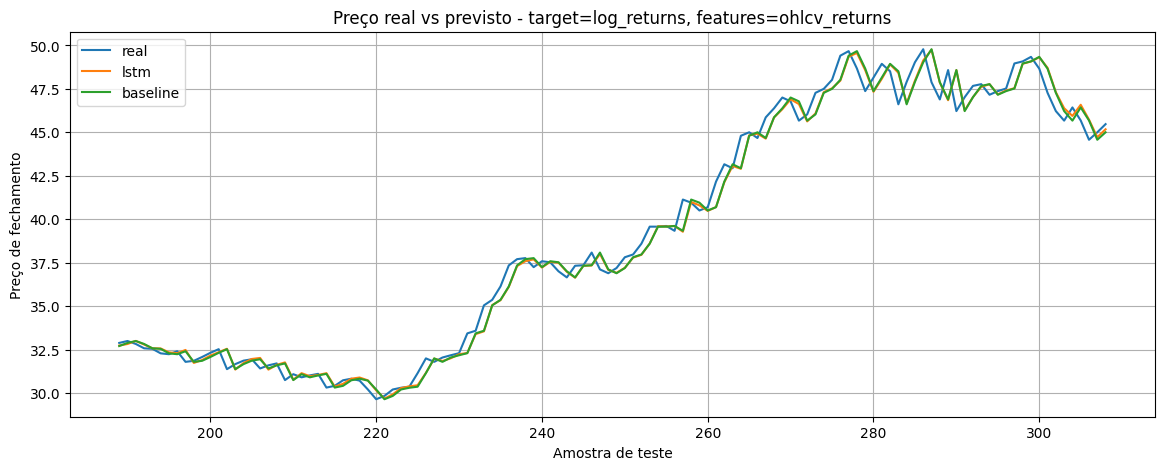

{'target_mode': 'log_returns',
 'feature_mode': 'ohlcv_returns',
 'lstm': {'mae': 0.43035578804880287,
  'rmse': 0.6138314685022308,
  'mape_pct': 1.196092908875157},
 'baseline_last_close': {'mae': 0.43433659747966286,
  'rmse': 0.6123784446860364,
  'mape_pct': 1.2049321192417377},
 'directional_accuracy_pct': 52.42718446601942,
 'improvement_vs_baseline_pct': {'mae': 0.9165263654869386,
  'rmse': -0.23727546728711954,
  'mape_pct': 0.7335857535396388}}

In [9]:
%matplotlib inline

model.eval()

test_loader = DataLoader(
    torch.tensor(X_test, dtype=torch.float32),
    batch_size=256,
    shuffle=False,
)

preds = []

with torch.inference_mode():
    for xb in test_loader:
        xb = xb.to(device)
        y_pred = model(xb)
        preds.append(y_pred.cpu().numpy())

pred_scaled = np.vstack(preds).reshape(-1)

y_true_close, y_pred_close = inverse_predictions_to_close(
    pred_scaled=pred_scaled,
    y_scaled=y_test.reshape(-1),
    last_close=last_close_test,
    y_scaler=exp_data["y_scaler"],
    target_mode=TRAIN_TARGET_MODE,
)

baseline_close = last_close_test

lstm_metrics = regression_metrics(y_true_close, y_pred_close)
baseline_metrics = regression_metrics(y_true_close, baseline_close)
directional_acc = directional_accuracy(y_true_close, y_pred_close, baseline_close)

metrics_df = pd.DataFrame(
    [
        {"modelo": "LSTM", **lstm_metrics},
        {"modelo": "Baseline último fechamento", **baseline_metrics},
    ]
).set_index("modelo")

lower_is_better = ["mae", "rmse", "mape_pct"]
improvement = {
    metric: (baseline_metrics[metric] - lstm_metrics[metric]) / baseline_metrics[metric] * 100
    for metric in lower_is_better
}

display(metrics_df.round(4))

print(f"Target mode: {TRAIN_TARGET_MODE}")
print(f"Feature mode: {INPUT_FEATURE_MODE}")
print(f"Acurácia direcional LSTM: {directional_acc:.2f}%")
print(
    "Melhora vs baseline: "
    f"MAE={improvement['mae']:.2f}% | "
    f"RMSE={improvement['rmse']:.2f}% | "
    f"MAPE={improvement['mape_pct']:.2f}%"
)

results_df = pd.DataFrame({
    "real": y_true_close,
    "lstm": y_pred_close,
    "baseline": baseline_close,
})

display(results_df.tail(20).round(4))

ax = results_df.tail(120).plot(
    figsize=(14, 5),
    title=f"Preço real vs previsto - target={TRAIN_TARGET_MODE}, features={INPUT_FEATURE_MODE}",
)

ax.set_xlabel("Amostra de teste")
ax.set_ylabel("Preço de fechamento")
ax.grid(True)
plt.show()

metrics = {
    "target_mode": TRAIN_TARGET_MODE,
    "feature_mode": INPUT_FEATURE_MODE,
    "lstm": lstm_metrics,
    "baseline_last_close": baseline_metrics,
    "directional_accuracy_pct": directional_acc,
    "improvement_vs_baseline_pct": improvement,
}

metrics


## 9. Predições de teste

Tabela curta para inspecionar previsões contra valores reais.

In [10]:
predictions = pd.DataFrame({
    "target_date": pd.to_datetime(dates_test),
    "last_close": baseline_close,
    "actual_close": y_true_close,
    "predicted_close_lstm": y_pred_close,
    "absolute_error_lstm": np.abs(y_true_close - y_pred_close),
    "absolute_error_baseline": np.abs(y_true_close - baseline_close),
})

predictions.tail(10)

,target_date,last_close,actual_close,predicted_close_lstm,absolute_error_lstm,absolute_error_baseline
299,2026-05-04,49.080002,49.340000,49.075527,0.264473,0.259998
300,2026-05-05,49.340000,48.660000,49.319248,0.659248,0.680000
301,2026-05-06,48.660000,47.270004,48.708927,1.438923,1.389996
302,2026-05-07,47.270000,46.220001,47.306900,1.086899,1.049999
303,2026-05-08,46.220001,45.669998,46.385254,0.715256,0.550003
304,2026-05-11,45.669998,46.430000,45.941711,0.488289,0.760002
305,2026-05-12,46.430000,45.680000,46.583584,0.903584,0.750000
306,2026-05-13,45.680000,44.570004,45.726925,1.156921,1.109997
307,2026-05-14,44.570000,45.000000,44.718029,0.281971,0.430000
308,2026-05-15,45.000000,45.469997,45.173519,0.296478,0.469997


## 10. Treinamento oficial por log-retornos

Quando quiser gerar os artefatos usados pela API, rode o pipeline oficial. Ele sempre usa log-retornos, independentemente da flag experimental acima.

In [11]:
# Descomente para gerar model.pt, preprocessor.joblib e métricas usados pela API.
# results = run_training_pipeline(cfg)
# results["metrics"]

## 11. Payload para a API

A API oficial atual recebe lista cronológica de fechamentos. Com `window_size=60`, envie pelo menos 61 fechamentos.

Se você decidir levar `INPUT_FEATURE_MODE = "ohlcv_returns"` para produção, a API também precisa receber OHLCV e aplicar a mesma engenharia de features do treino.


In [12]:
recent_closes = close_frame["Close"].tail(cfg.window_size + 1).astype(float).tolist()
payload = {
    "symbol": cfg.symbol,
    "closes": recent_closes,
}

payload["closes"][:3], payload["closes"][-3:], len(payload["closes"])

([36.88999938964844, 37.189998626708984, 37.810001373291016],
 [44.56999969482422, 45.0, 45.470001220703125],
 61)

## 12. Próximos passos da demonstração

Com os artefatos salvos pelo treino oficial, suba a API no PowerShell com:

```powershell
$env:PYTHONPATH="src"; uvicorn api:app --reload
```

Depois acesse:

- `http://localhost:8000/` para abrir direto o dashboard;
- `http://localhost:8000/docs` para Swagger;
- `http://localhost:8000/model-card` para resumo do modelo;
- `http://localhost:8000/metrics` para Prometheus.